# NLP Pipeline -- Full Project Inspection Notebook

This notebook lets you **interactively inspect every part** of the new pipeline:

1. **Dataset Statistics** -- Total word count, per-topic breakdown
2. **Raw Embedding Values** -- The actual 384-dim numeric vectors
3. **Query Vector Dictionary** -- Numeric anchor vectors per topic
4. **K-Means Clustering** -- Where and how it runs (semi-supervised explanation)
5. **Cosine Distance Assignment** -- How clusters get labelled without true labels
6. **t-SNE Cluster Plot** -- 2D visualization of 384-dim embedding space
7. **Test Set Evaluation** -- Final accuracy and confusion matrix


In [1]:
import csv, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    homogeneity_score, completeness_score, v_measure_score
)
print('All imports OK.')


All imports OK.


---
## Section 1 -- Dataset Statistics
### How many words are in the dataset?

In [2]:
dataset_df = pd.read_csv('data/dataset.csv')
dataset_df['word_count'] = dataset_df['text'].apply(lambda x: len(str(x).split()))

total_words = dataset_df['word_count'].sum()
total_posts = len(dataset_df)

print('=' * 55)
print('      DATASET WORD COUNT SUMMARY')
print('=' * 55)
print(f'  Total posts  : {total_posts:,}')
print(f'  Total words  : {total_words:,}')
print()

per_topic = dataset_df.groupby('label').agg(
    Posts  = ('text',       'count'),
    Words  = ('word_count', 'sum'),
    Avg_wc = ('word_count', 'mean'),
    Max_wc = ('word_count', 'max'),
).reset_index()
per_topic['Avg_wc'] = per_topic['Avg_wc'].round(1)
print(per_topic.to_string(index=False))


      DATASET WORD COUNT SUMMARY
  Total posts  : 1,417
  Total words  : 75,545

   label  Posts  Words  Avg_wc  Max_wc
  Health    437  25202    57.7     810
Politics    490  25169    51.4    2763
  Sports    490  25174    51.4    2763


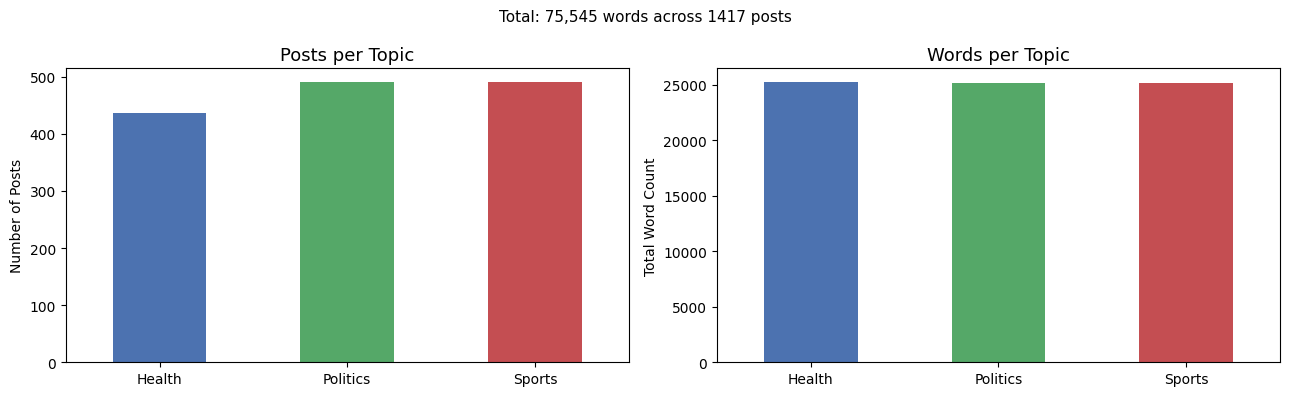

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
per_topic.plot.bar(x='label', y='Posts', ax=axes[0],
                   color=['#4C72B0','#55A868','#C44E52'], legend=False)
axes[0].set_title('Posts per Topic', fontsize=13)
axes[0].set_xlabel(''); axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=0)
per_topic.plot.bar(x='label', y='Words', ax=axes[1],
                   color=['#4C72B0','#55A868','#C44E52'], legend=False)
axes[1].set_title('Words per Topic', fontsize=13)
axes[1].set_xlabel(''); axes[1].set_ylabel('Total Word Count')
axes[1].tick_params(axis='x', rotation=0)
plt.suptitle(f'Total: {total_words:,} words across {total_posts} posts', fontsize=11)
plt.tight_layout()
plt.show()


---
## Section 2 -- Raw SBERT Embedding Numeric Values
### Each sentence becomes a vector of 384 numbers

In [4]:
with open('data/train_embeddings.pkl', 'rb') as f:
    emb_data = pickle.load(f)

embeddings   = emb_data['embeddings']
train_labels = emb_data['labels']

print(f'Embedding matrix shape : {embeddings.shape}')
print(f'  -> {embeddings.shape[0]} sentences x {embeddings.shape[1]} dimensions')
print(f'  -> dtype: {embeddings.dtype}')
print(f'  -> value range: [{embeddings.min():.4f}, {embeddings.max():.4f}]')


Embedding matrix shape : (991, 384)
  -> 991 sentences x 384 dimensions
  -> dtype: float32
  -> value range: [-0.2253, 0.2484]


In [5]:
train_df = pd.read_csv('data/train.csv')
print('FIRST 10 SENTENCES AND THEIR SBERT EMBEDDINGS')
print('=' * 80)
for i in range(10):
    print(f'\nSentence {i+1} [{train_labels[i]}]:')
    print(f'  Text   : {train_df["text"].iloc[i][:120]}...')
    print(f'  Vector : [' + ' '.join(f'{v:.5f}' for v in embeddings[i][:20]) + ' ...]')
    print(f'  (showing first 20 of {embeddings.shape[1]} dimensions)')
    print('-' * 80)


FIRST 10 SENTENCES AND THEIR SBERT EMBEDDINGS

Sentence 1 [Health]:
  Text   : PLEASE PRAY WITH ME OVER MY HEALTH AND MY ANKLE Hey yall:)   I just wanted to ask that you may join me in prayer over my...
  Vector : [-0.02024 -0.02980 0.01672 -0.04460 0.02352 -0.02332 0.02563 -0.04530 0.00416 -0.07627 -0.10276 0.09146 0.02397 0.01407 -0.01613 0.01802 -0.05958 0.03322 -0.08711 0.07791 ...]
  (showing first 20 of 384 dimensions)
--------------------------------------------------------------------------------

Sentence 2 [Health]:
  Text   : Americans Hate Their Private Health Insurance...
  Vector : [0.05178 0.08213 0.03724 -0.00290 0.05393 0.04152 0.05056 -0.00413 0.02419 0.02338 0.01156 0.05008 -0.02299 -0.08986 -0.08483 -0.04307 0.00193 -0.06814 0.02092 0.12920 ...]
  (showing first 20 of 384 dimensions)
--------------------------------------------------------------------------------

Sentence 3 [Health]:
  Text   : BYU Student Health Center?? Hi, I am a freshman at BYU and am currently

In [6]:
# Change INDEX (0-990) to inspect any sentence
INDEX = 42

sentence = train_df['text'].iloc[INDEX]
label    = train_labels[INDEX]
vector   = embeddings[INDEX]

print(f'Index : {INDEX}  |  Topic : {label}')
print(f'Text  : {sentence[:200]}')
print(f'\nFull 384-dim vector (8 values per row):')
for row_start in range(0, 384, 8):
    vals = vector[row_start:row_start+8]
    print(f'  dims {row_start:3d}-{row_start+len(vals)-1:3d}: ' +
          ' '.join(f'{v:+.5f}' for v in vals))


Index : 42  |  Topic : Health
Text  : German ad for mental health

Full 384-dim vector (8 values per row):
  dims   0-  7: +0.01454 +0.01121 -0.04818 +0.06254 +0.01987 +0.11368 +0.12711 +0.03309
  dims   8- 15: +0.02818 -0.10037 +0.05695 -0.04054 -0.06548 -0.00905 +0.04468 +0.03422
  dims  16- 23: +0.00153 +0.02099 +0.03971 +0.04312 -0.05966 +0.04818 +0.07260 +0.01086
  dims  24- 31: +0.04179 +0.02453 +0.00133 -0.10681 -0.01124 +0.04551 +0.10039 +0.04088
  dims  32- 39: +0.05308 -0.04154 +0.08599 -0.04100 -0.00318 -0.00203 -0.05098 +0.03644
  dims  40- 47: -0.07909 -0.03653 +0.00066 -0.03582 -0.04997 -0.01514 -0.00099 +0.04955
  dims  48- 55: -0.00895 -0.01122 -0.03441 -0.02466 +0.06113 +0.04156 +0.03357 -0.04164
  dims  56- 63: +0.07980 -0.00174 -0.08857 +0.12254 -0.00677 +0.00796 -0.05233 +0.05418
  dims  64- 71: +0.02523 +0.05866 -0.06404 -0.00876 -0.04346 -0.01489 +0.02650 -0.11794
  dims  72- 79: -0.01538 +0.06371 +0.05027 -0.02476 -0.08298 -0.01286 +0.11679 -0.05683
  dims  80- 8

In [7]:
# Full embedding matrix as scrollable DataFrame
dim_cols = [f'dim_{i}' for i in range(embeddings.shape[1])]
emb_df   = pd.DataFrame(embeddings, columns=dim_cols)
emb_df.insert(0, 'label', train_labels)
print(f'Shape: {emb_df.shape}  (scroll right to see all 384 dim columns)')
emb_df.head(10)


Shape: (991, 385)  (scroll right to see all 384 dim columns)


,label,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_374,dim_375,dim_376,dim_377,dim_378,dim_379,dim_380,dim_381,dim_382,dim_383
0,Health,-0.020243,-0.029801,0.016720,-0.044599,0.023519,-0.023318,0.025633,-0.045300,0.004157,...,-0.016957,0.076959,-0.052960,-0.000663,-0.016162,0.001315,0.019233,-0.062311,-0.038570,-0.009098
1,Health,0.051776,0.082129,0.037235,-0.002901,0.053929,0.041518,0.050561,-0.004128,0.024187,...,-0.002256,-0.010412,0.011554,-0.019974,-0.029298,0.013942,-0.019214,-0.031710,0.072255,0.078473
2,Health,-0.030464,0.036888,0.080008,-0.019865,-0.017237,-0.002986,0.010109,0.015723,-0.047732,...,-0.021163,0.028704,0.028976,-0.099562,-0.023933,0.014639,-0.043470,-0.091545,-0.040005,0.014744
3,Health,0.000784,0.059026,-0.051603,0.026728,0.005343,-0.000545,-0.004384,0.054110,-0.007513,...,-0.027743,0.008626,0.039274,-0.016009,-0.132484,0.119284,0.044991,-0.154882,0.039457,0.026651
4,Health,-0.044158,0.033117,0.043003,-0.006849,0.014024,-0.005291,0.052577,-0.018603,-0.076982,...,0.029027,0.039168,0.002237,0.036026,0.005210,-0.009900,0.012003,-0.078609,-0.009624,0.042552
5,Health,0.022899,0.158499,-0.011040,-0.032837,-0.004336,0.037743,0.063515,0.025630,0.017067,...,-0.004145,-0.013142,0.026551,0.002481,-0.119077,0.034840,0.039694,-0.114364,0.061231,0.020167
6,Health,-0.017405,0.049779,-0.069762,-0.005794,0.012124,0.032274,-0.031296,0.016738,0.001293,...,0.078493,0.126498,0.008479,-0.027647,-0.120395,-0.125674,-0.009343,-0.069225,0.011072,0.033438
7,Health,-0.074862,0.110294,-0.009589,-0.002886,0.015538,-0.019361,0.065786,0.027934,-0.035361,...,-0.055309,0.052389,0.031050,0.003884,-0.024954,0.132003,0.020917,-0.006348,0.001920,0.078996
8,Health,-0.082753,-0.008827,-0.036934,0.048774,0.026351,0.015093,-0.000566,0.011717,0.000786,...,-0.016930,0.065504,0.004231,-0.045569,0.011557,0.011792,0.132416,-0.043164,-0.037034,-0.002006
9,Health,-0.072961,-0.062744,-0.016415,-0.044581,0.080297,0.051937,0.014974,-0.034427,-0.048694,...,-0.032857,0.135379,0.009189,-0.021260,-0.028257,0.061612,0.055444,0.041934,-0.034257,0.056763


---
## Section 3 -- Query Vector Dictionary (Numeric Values)
### These are the SBERT-encoded topic anchors used for cluster labeling

In [8]:
with open('data/query_vectors.pkl', 'rb') as f:
    query_vectors = pickle.load(f)

print('QUERY VECTOR DICTIONARY')
print('=' * 80)
for topic, vec in query_vectors.items():
    print(f'\nTopic  : {topic}   |   shape: {vec.shape}')
    print(f'  First 20 dims : [' + ' '.join(f'{v:+.5f}' for v in vec[:20]) + ' ...]')
    print(f'  L2 norm       : {np.linalg.norm(vec):.4f}')
    print(f'  Value range   : [{vec.min():.4f}, {vec.max():.4f}]')


QUERY VECTOR DICTIONARY

Topic  : Sports   |   shape: (384,)
  First 20 dims : [-0.00294 +0.08853 -0.02891 -0.02265 +0.00988 +0.06017 +0.04973 +0.05672 +0.06261 +0.06029 -0.04614 -0.03985 +0.01640 +0.04319 -0.00882 -0.01555 -0.01694 -0.01456 -0.03118 -0.08234 ...]
  L2 norm       : 0.6382
  Value range   : [-0.0899, 0.1157]

Topic  : Health   |   shape: (384,)
  First 20 dims : [+0.00516 +0.03932 -0.01291 +0.03225 -0.02951 +0.02779 +0.05801 +0.04878 -0.00186 -0.01110 -0.00727 +0.01590 -0.01426 -0.02109 -0.01632 -0.01049 +0.03336 +0.01286 -0.00137 +0.01654 ...]
  L2 norm       : 0.5531
  Value range   : [-0.0815, 0.0741]

Topic  : Politics   |   shape: (384,)
  First 20 dims : [-0.01194 +0.03476 +0.00330 +0.00276 +0.01850 +0.03775 +0.04975 -0.00790 -0.04907 +0.02933 -0.00783 +0.03238 -0.01552 -0.00107 +0.01368 +0.04576 -0.02658 +0.00114 -0.05082 +0.03140 ...]
  L2 norm       : 0.5792
  Value range   : [-0.0867, 0.1273]


In [9]:
# DataFrame view of all 3 query vectors (3 rows x 384 cols)
topics  = list(query_vectors.keys())
qv_mat  = np.stack(list(query_vectors.values()))
qv_df   = pd.DataFrame(qv_mat, columns=[f'dim_{i}' for i in range(384)], index=topics)
print(f'Shape: {qv_df.shape}  (scroll right for all 384 dims)')
qv_df


Shape: (3, 384)  (scroll right for all 384 dims)


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_374,dim_375,dim_376,dim_377,dim_378,dim_379,dim_380,dim_381,dim_382,dim_383
Sports,-0.002935,0.088528,-0.028911,-0.022653,0.009880,0.060175,0.049732,0.056718,0.062612,0.060287,...,-0.001444,0.022634,-0.016985,-0.013003,-0.038495,0.019381,0.037907,-0.008864,-0.007195,-0.012195
Health,0.005163,0.039316,-0.012912,0.032246,-0.029507,0.027786,0.058007,0.048778,-0.001858,-0.011100,...,-0.021905,0.054014,0.021602,-0.012327,-0.041644,-0.030403,0.037391,-0.014557,0.039015,-0.003821
Politics,-0.011941,0.034757,0.003297,0.002759,0.018502,0.037755,0.049748,-0.007900,-0.049066,0.029332,...,0.042403,0.029166,-0.006278,0.005193,-0.011189,0.016413,0.037101,0.020314,0.010074,-0.030202


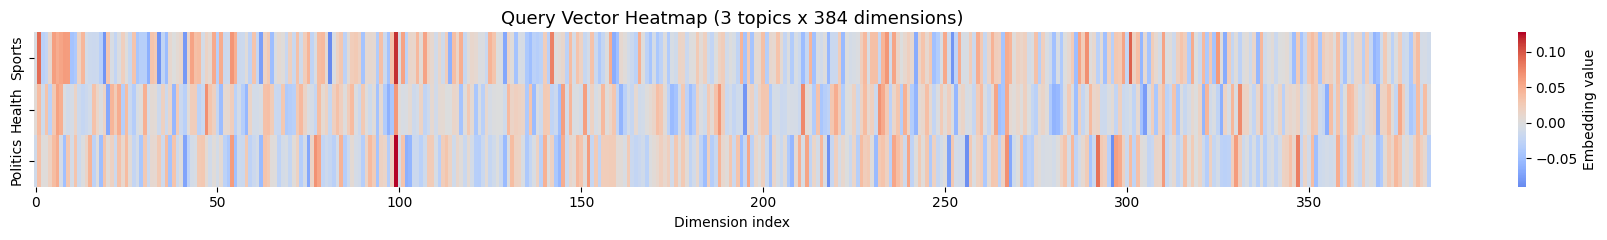

In [10]:
fig, ax = plt.subplots(figsize=(18, 2.5))
sns.heatmap(qv_df.values, ax=ax, cmap='coolwarm', center=0,
            linewidths=0, xticklabels=50, yticklabels=topics,
            cbar_kws={'label': 'Embedding value'})
ax.set_title('Query Vector Heatmap (3 topics x 384 dimensions)', fontsize=13)
ax.set_xlabel('Dimension index')
plt.tight_layout()
plt.show()


---
## Section 4 -- K-Means Clustering (Semi-Supervised Explanation)

### Why this is Semi-Supervised:

| Step | Uses True Labels? | Type |
|---|---|---|
| K-Means training | NO -- only sees embedding coordinates | Unsupervised |
| Cluster labeling | NO -- uses cosine distance to query vectors | Unsupervised |
| Query dictionary | YES -- hand-crafted topic anchor phrases | Supervised signal |
| Test evaluation | YES -- compares predictions to true labels | Supervised |

K-Means clusters the data blindly. Then we use expert-written phrases (the query dict)
as a supervised signal to **name** the clusters -- making the overall system semi-supervised.


In [11]:
print('Running K-Means (n=3) on 991 training embeddings of 384 dimensions...')
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

print(f'\nCluster counts:')
for c, count in sorted(Counter(cluster_labels).items()):
    print(f'  Cluster {c}: {count} sentences')

print(f'\nCluster centroids shape: {kmeans.cluster_centers_.shape}')


Running K-Means (n=3) on 991 training embeddings of 384 dimensions...

Cluster counts:
  Cluster 0: 340 sentences
  Cluster 1: 342 sentences
  Cluster 2: 309 sentences

Cluster centroids shape: (3, 384)


In [12]:
print('CLUSTER CENTROID VECTORS (mean position in 384-dim space)')
print('=' * 80)
for c_id, centroid in enumerate(kmeans.cluster_centers_):
    print(f'\nCluster {c_id} centroid (first 20 of 384 dims):')
    print('  [' + ' '.join(f'{v:+.5f}' for v in centroid[:20]) + ' ...]')
    print(f'  L2 norm: {np.linalg.norm(centroid):.4f}')


CLUSTER CENTROID VECTORS (mean position in 384-dim space)

Cluster 0 centroid (first 20 of 384 dims):
  [+0.00163 +0.03392 -0.00561 -0.03535 +0.02280 +0.02941 +0.02374 +0.01262 +0.02060 +0.04087 -0.03710 -0.00502 -0.01247 +0.02994 +0.01151 -0.01326 +0.01439 -0.02279 -0.01192 -0.00488 ...]
  L2 norm: 0.4261

Cluster 1 centroid (first 20 of 384 dims):
  [+0.00461 -0.00167 +0.00139 -0.00993 +0.03768 +0.01546 +0.02799 -0.02179 -0.00724 -0.00637 -0.02038 +0.01356 +0.00093 -0.00557 -0.00069 +0.02056 -0.00896 -0.02650 -0.01317 +0.03825 ...]
  L2 norm: 0.4320

Cluster 2 centroid (first 20 of 384 dims):
  [+0.01124 +0.03008 +0.00616 +0.02684 +0.02209 +0.02011 +0.02248 +0.01367 -0.02266 -0.01911 -0.00593 +0.02293 -0.01840 -0.01776 +0.00248 -0.01216 +0.01629 -0.01932 -0.03034 +0.04855 ...]
  L2 norm: 0.4230


---
## Section 5 -- Cosine Distance: How Clusters Get Labelled

In [13]:
def cosine_distance(a, b):
    return 1.0 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

label_mapping = {}
all_distances = []

print('COSINE DISTANCE: Cluster Centroids vs Topic Query Vectors')
print('Lower = more similar = cluster assigned to that topic')
print('=' * 65)

for c_id, centroid in enumerate(kmeans.cluster_centers_):
    row = {'Cluster': f'Cluster {c_id}'}
    distances = {}
    for topic in topics:
        d = cosine_distance(centroid, query_vectors[topic])
        distances[topic] = d
        row[topic] = round(d, 4)
    assigned = min(distances, key=distances.get)
    row['Assigned'] = assigned
    label_mapping[c_id] = assigned
    all_distances.append(row)

dist_df = pd.DataFrame(all_distances).set_index('Cluster')
print(dist_df.to_string())
print('\nFinal mapping:', label_mapping)


COSINE DISTANCE: Cluster Centroids vs Topic Query Vectors
Lower = more similar = cluster assigned to that topic
           Sports  Health  Politics  Assigned
Cluster                                      
Cluster 0  0.3824  0.8633    0.8850    Sports
Cluster 1  0.9668  0.8998    0.3617  Politics
Cluster 2  1.0170  0.3069    0.8443    Health

Final mapping: {0: 'Sports', 1: 'Politics', 2: 'Health'}


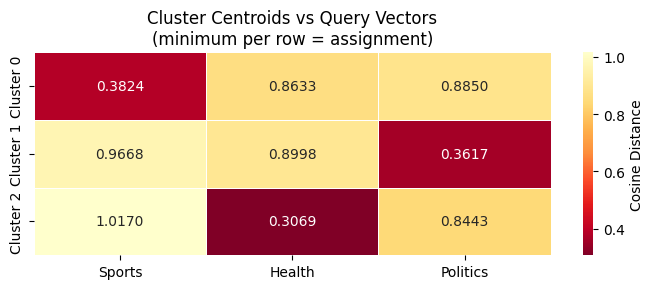

In [14]:
fig, ax = plt.subplots(figsize=(7, 3))
heat_data = dist_df[topics].values.astype(float)
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlOrRd_r',
            xticklabels=topics, yticklabels=dist_df.index.tolist(),
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Cosine Distance'})
ax.set_title('Cluster Centroids vs Query Vectors\n(minimum per row = assignment)', fontsize=12)
plt.tight_layout()
plt.show()


---
## Section 6 -- t-SNE Cluster Plot
### 384 dimensions compressed to 2 for visualization

In [15]:
print('Running t-SNE ... (~30-60 seconds)')
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000, verbose=1)
coords_2d = tsne.fit_transform(embeddings)
print(f'Done. Output shape: {coords_2d.shape}')


Running t-SNE ... (~30-60 seconds)
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 991 samples in 0.001s...
[t-SNE] Computed neighbors for 991 samples in 0.104s...
[t-SNE] Computed conditional probabilities for sample 991 / 991
[t-SNE] Mean sigma: 0.334002
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.071930
[t-SNE] KL divergence after 1000 iterations: 1.125405
Done. Output shape: (991, 2)


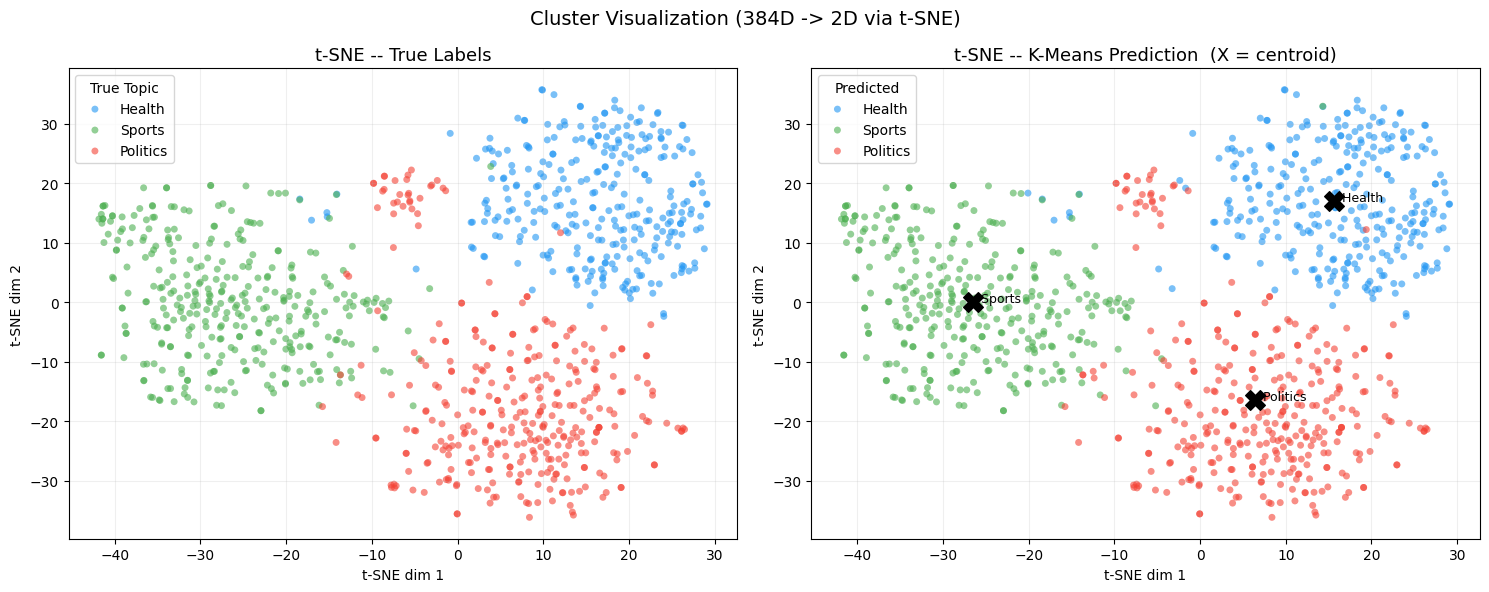

Saved as cluster_plot_notebook.png


In [16]:
palette = {'Health': '#2196F3', 'Sports': '#4CAF50', 'Politics': '#F44336'}
predicted_names = [label_mapping[c] for c in cluster_labels]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for label, color in palette.items():
    mask = np.array(train_labels) == label
    axes[0].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    c=color, label=label, alpha=0.6, s=25, edgecolors='none')
axes[0].set_title('t-SNE -- True Labels', fontsize=13)
axes[0].legend(title='True Topic'); axes[0].grid(alpha=0.2)
axes[0].set_xlabel('t-SNE dim 1'); axes[0].set_ylabel('t-SNE dim 2')

for label, color in palette.items():
    mask = np.array(predicted_names) == label
    axes[1].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    c=color, label=label, alpha=0.6, s=25, edgecolors='none')
for c_id in range(3):
    c_mask = cluster_labels == c_id
    cx, cy = coords_2d[c_mask, 0].mean(), coords_2d[c_mask, 1].mean()
    axes[1].scatter(cx, cy, c='black', s=200, marker='X', zorder=5)
    axes[1].annotate(f'  {label_mapping[c_id]}', (cx, cy), fontsize=9)
axes[1].set_title('t-SNE -- K-Means Prediction  (X = centroid)', fontsize=13)
axes[1].legend(title='Predicted'); axes[1].grid(alpha=0.2)
axes[1].set_xlabel('t-SNE dim 1'); axes[1].set_ylabel('t-SNE dim 2')

plt.suptitle('Cluster Visualization (384D -> 2D via t-SNE)', fontsize=14)
plt.tight_layout()
plt.savefig('cluster_plot_notebook.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as cluster_plot_notebook.png')


---
## Section 7 -- Test Set Evaluation
### Validating on the 30% held-out test data (never seen during training)

In [17]:
from sentence_transformers import SentenceTransformer

test_df     = pd.read_csv('data/test.csv')
test_texts  = test_df['text'].tolist()
test_labels = test_df['label'].tolist()

print(f'Test set: {len(test_texts)} samples')
print('Encoding with SBERT...')
sbert = SentenceTransformer('all-MiniLM-L6-v2')
test_embeddings = sbert.encode(test_texts, convert_to_numpy=True)
print(f'Done. Shape: {test_embeddings.shape}')


Test set: 426 samples
Encoding with SBERT...
Done. Shape: (426, 384)


In [18]:
cluster_preds    = kmeans.predict(test_embeddings)
predicted_topics = [label_mapping[c] for c in cluster_preds]
acc              = accuracy_score(test_labels, predicted_topics)
topic_order      = ['Health', 'Politics', 'Sports']

print('=' * 55)
print('      TEST SET EVALUATION REPORT')
print('=' * 55)
print(f'  Samples          : {len(test_labels)}')
print(f'  Overall Accuracy : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  Homogeneity      : {homogeneity_score(test_labels, predicted_topics):.4f}')
print(f'  Completeness     : {completeness_score(test_labels, predicted_topics):.4f}')
print(f'  V-Measure        : {v_measure_score(test_labels, predicted_topics):.4f}')
print('=' * 55)


      TEST SET EVALUATION REPORT
  Samples          : 426
  Overall Accuracy : 0.9695  (96.9%)
  Homogeneity      : 0.8630
  Completeness     : 0.8628
  V-Measure        : 0.8629


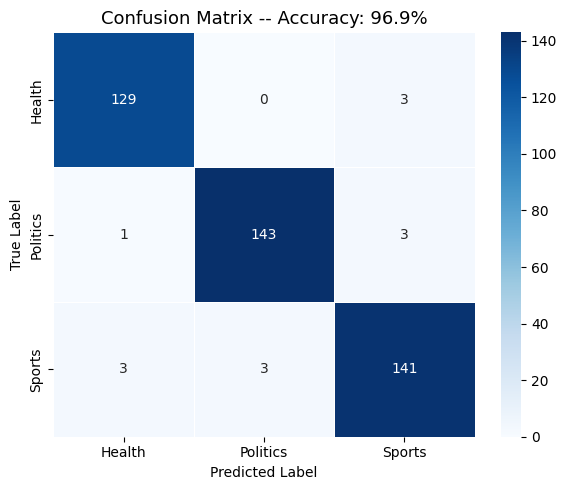

          Health  Politics  Sports
Health       129         0       3
Politics       1       143       3
Sports         3         3     141


In [19]:
cm    = confusion_matrix(test_labels, predicted_topics, labels=topic_order)
cm_df = pd.DataFrame(cm, index=topic_order, columns=topic_order)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
ax.set_title(f'Confusion Matrix -- Accuracy: {acc*100:.1f}%', fontsize=13)
plt.tight_layout()
plt.show()
print(cm_df.to_string())


In [20]:
print('MAJORITY CLUSTER VALIDATION (per topic)')
print('=' * 60)
for topic in topic_order:
    indices = [i for i, t in enumerate(test_labels) if t == topic]
    preds   = [predicted_topics[i] for i in indices]
    maj, cnt = Counter(preds).most_common(1)[0]
    status = '[OK]' if maj == topic else '[FAIL]'
    print(f'  {topic:10s}: majority={maj:10s} ({cnt}/{len(indices)}) {status}')


MAJORITY CLUSTER VALIDATION (per topic)
  Health    : majority=Health     (129/132) [OK]
  Politics  : majority=Politics   (143/147) [OK]
  Sports    : majority=Sports     (141/147) [OK]


---
## Section 8 -- Interactive Query UI
### Type a query into the text box and click 'Search' to see the predicted topic and nearest documents!

In [21]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
import pickle
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# 1. Load the model and data
try:
    if 'sbert' not in globals():
        sbert = SentenceTransformer('all-MiniLM-L6-v2')
    
    with open('data/train_embeddings.pkl', 'rb') as f:
        _d = pickle.load(f)
    embeddings, train_labels = _d['embeddings'], _d['labels']
    train_df = pd.read_csv('data/train.csv')
    
    with open('data/query_vectors.pkl', 'rb') as f:
        query_vectors = pickle.load(f)
    topics = list(query_vectors.keys())
    
    # Recreate the trained clustering if needed
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    label_mapping = {}
    for c_id, centroid in enumerate(kmeans.cluster_centers_):
        dists = {t: 1.0 - np.dot(centroid, query_vectors[t]) /
                 (np.linalg.norm(centroid) * np.linalg.norm(query_vectors[t]) + 1e-9)
                 for t in topics}
        label_mapping[c_id] = min(dists, key=dists.get)

except Exception as e:
    print("Error loading models/data. Make sure previous cells were run.", e)

# 2. Build the UI
text_input = widgets.Text(
    value='',
    placeholder='Type your query here (e.g. Who won the game?)',
    description='Query:',
    layout=widgets.Layout(width='80%')
)
search_button = widgets.Button(
    description='Search Cluster',
    button_style='info',
    tooltip='Search the cluster based on cosine distance'
)
out = widgets.Output()

def on_search_clicked(b):
    with out:
        clear_output()
        query = text_input.value.strip()
        if not query:
            print("Please enter a query.")
            return
            
        print("="*70)
        print(f"  SEARCHING: '{query}'")
        print("="*70)
        
        # SBERT Encode
        query_vec = sbert.encode([query], convert_to_numpy=True)[0]
        
        # Cosine distance to topic anchors
        topic_distances = {}
        for t in topics:
            cos_dist = 1.0 - np.dot(query_vec, query_vectors[t]) / (np.linalg.norm(query_vec) * np.linalg.norm(query_vectors[t]) + 1e-9)
            topic_distances[t] = cos_dist
            
        predicted_topic = min(topic_distances, key=topic_distances.get)
        
        print(f"\n  ⭐ PREDICTED CLUSTER / TOPIC : {predicted_topic.upper()} ⭐\n")
        
        print("  Cosine distances (lower is better):")
        for t, d in sorted(topic_distances.items(), key=lambda x: x[1]):
            marker = "  <-- BEST MATCH" if t == predicted_topic else ""
            print(f"    {t:10s}: {d:.4f}{marker}")
            
        # Nearest documents
        cos_sims = embeddings @ query_vec / (
            np.linalg.norm(embeddings, axis=1) * np.linalg.norm(query_vec) + 1e-9
        )
        top3_idx = np.argsort(cos_sims)[::-1][:3]
        
        print("\n  Top-3 nearest documents in the database:")
        print("  " + "-"*66)
        for rank, idx in enumerate(top3_idx, 1):
            sim = cos_sims[idx]
            lbl = train_labels[idx]
            text = train_df['text'].iloc[idx][:150].replace('\n', ' ')
            print(f"  #{rank}  Similarity={sim:.4f}  |  True Label={lbl}")
            print(f"      {text}...")
            print("  " + "-"*66)

search_button.on_click(on_search_clicked)

# Display the UI
display(widgets.VBox([widgets.HBox([text_input, search_button]), out]))
